# Power of revealed preference tests: simulation notebook
This notebook contains code to perform simulations and plot figures related to my project on the power of revealed preference tests.

In [2]:
from power_rptests.data_generation import *
from power_rptests.data_plotting import *
import pickle
import openpyxl

path = "/Users/federicobassi/Desktop/power_rptests"
simulated_data = path + "/simulated_data"
figures = path + "/figures/"

palette_okabe_ito = ["#08519c", "#3182bd", "#6baed6", "#c6dbef"]
palette_gray = ["#1f1f1f", "#4c4c4c", "#7f7f7f","#b2b2b2",]

## Simulation setup
Specify the parameters that we want to keep constant across simulations:
- utility function
- parameter distribution
- noise type
- noise parameters
- num_samples
- seed

Specify the budget constraints:
- Andreoni and Miller
- Optimized

In [3]:
# Constants across simulations
utility_function = "ces"
param_distribution = { "ces": {"alpha": lambda rng: rng.uniform(0.5, 1),
                                "rho":   lambda rng: rng.uniform(-0.5, 0.95),}}
#noise_type = "jittering"
#noise_std = [50, 100, 150, 200]
#free_disposal = False
noise_type = "quantal_response"
lambda_qr = 0.1
n_sample = 1000
seed = 1234

# Budget constraints
andreoni_miller_budgets = [(120, 40), (40, 120), (120, 60), (60, 120), (150, 75),
                               (75, 150), (60, 60), (100, 100), (80, 80), (160, 40), (40, 160)]
andreoni_miller_budgets = [(10*ms, 10*mo) for ms, mo in andreoni_miller_budgets]
andreoni_miller_budgets.sort(key=lambda x: x[0])
andreoni_miller_budgets = {"budgets": andreoni_miller_budgets, "label":"Andreoni-Miller budgets"}

with open(simulated_data+"/budget_constraints_alg2.pkl", "rb") as f:
    optimized_budgets = pickle.load(f)
optimized_budgets.sort(key=lambda x: x[0])
optimized_budgets = {"budgets": optimized_budgets, "label":"Optimised budgets"}

## Generate data

In [4]:
df_andreoni_miller = simulate(
        budgets = andreoni_miller_budgets,
        utility_name = utility_function,
        param_distributions = param_distribution,
        noise_type = noise_type,
        std = noise_std,
        free_disposal = free_disposal,
        n_samples = n_sample,
        seed = seed
)

df_optimized = simulate(
        budgets = optimized_budgets,
        utility_name = utility_function,
        param_distributions = param_distribution,
        noise_type = noise_type,
        std = noise_std,
        free_disposal = free_disposal,
        n_samples = n_sample,
        seed = seed
)

NameError: name 'noise_std' is not defined

## Simulation 2: New set of budget constraints

In [4]:
"""
plot(df_andreoni_miller, 
     what="noisy", 
     noise_param=100, 
     noise_type="jittering", 
     domain="risk_preferences")
"""

'\nplot(df_andreoni_miller, \n     what="noisy", \n     noise_param=100, \n     noise_type="jittering", \n     domain="risk_preferences")\n'

In [5]:
df_am = df_andreoni_miller
df_opt = df_optimized
index_type = "CCEI"
threshold = 0.95
budget_label_col = "budget_label"
noise_param_col = "noise_param"

In [6]:
idx_am = compute_index(df_andreoni_miller)
idx_opt = compute_index(df_optimized)

if budget_label_col not in idx_am.columns:
        idx_am = idx_am.merge(df_am[["id", budget_label_col]].drop_duplicates(), on="id", how="left")
if budget_label_col not in idx_opt.columns:
        idx_opt = idx_opt.merge(df_opt[["id", budget_label_col]].drop_duplicates(), on="id", how="left")

if noise_param_col not in idx_am.columns:
        idx_am = idx_am.merge(df_am[["id", noise_param_col]].drop_duplicates(), on="id", how="left")
if noise_param_col not in idx_opt.columns:
        idx_opt = idx_opt.merge(df_opt[["id", noise_param_col]].drop_duplicates(), on="id", how="left")

score_col = index_type.upper()
idx_am["_rational"] = (idx_am[score_col] >= threshold)
idx_opt["_rational"] = (idx_opt[score_col] >= threshold)

g_am = idx_am.groupby([noise_param_col, budget_label_col], observed=True)["_rational"].mean().reset_index()
g_opt = idx_opt.groupby([noise_param_col, budget_label_col], observed=True)["_rational"].mean().reset_index()

g_am["share_pct"] = 100.0 * g_am["_rational"]
g_opt["share_pct"] = 100.0 * g_opt["_rational"]

comp = pd.concat([g_am, g_opt], ignore_index = True)

In [7]:
comp

,noise_param,budget_label,_rational,share_pct
0,50,Andreoni-Miller budgets,1.0000,100.00
1,100,Andreoni-Miller budgets,0.9949,99.49
2,150,Andreoni-Miller budgets,0.9462,94.62
3,200,Andreoni-Miller budgets,0.8465,84.65
4,50,Optimised budgets,0.9907,99.07
5,100,Optimised budgets,0.8306,83.06
6,150,Optimised budgets,0.6060,60.60
7,200,Optimised budgets,0.4264,42.64


In [8]:
noise_vals = comp[noise_param_col].dropna().unique().tolist()

In [9]:
noise_vals

[50, 100, 150, 200]

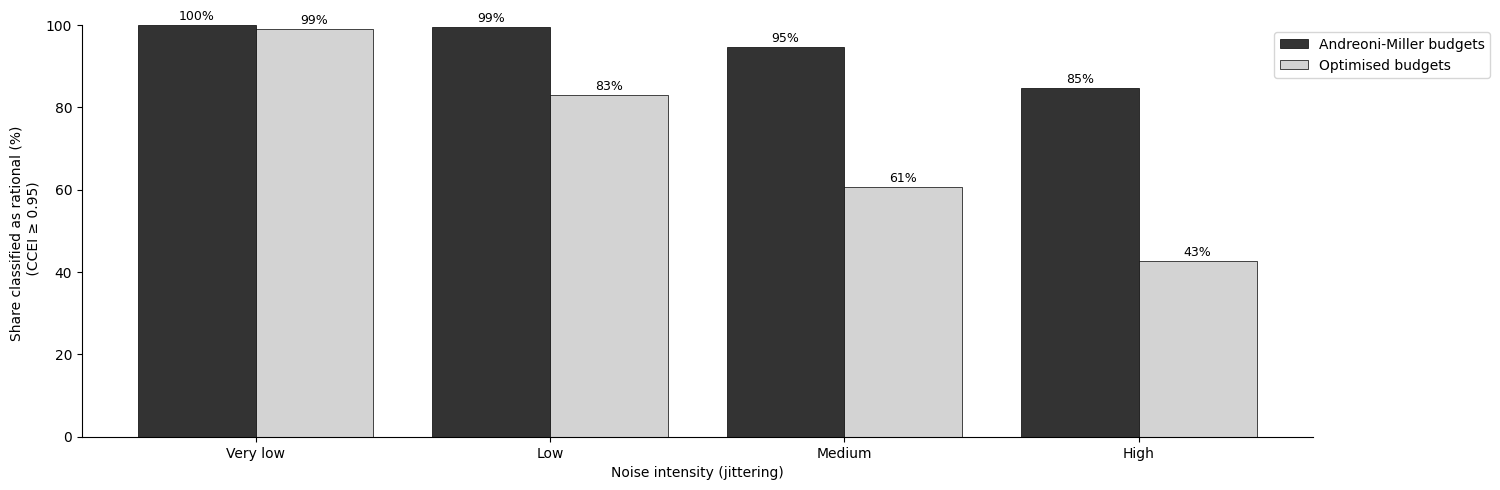

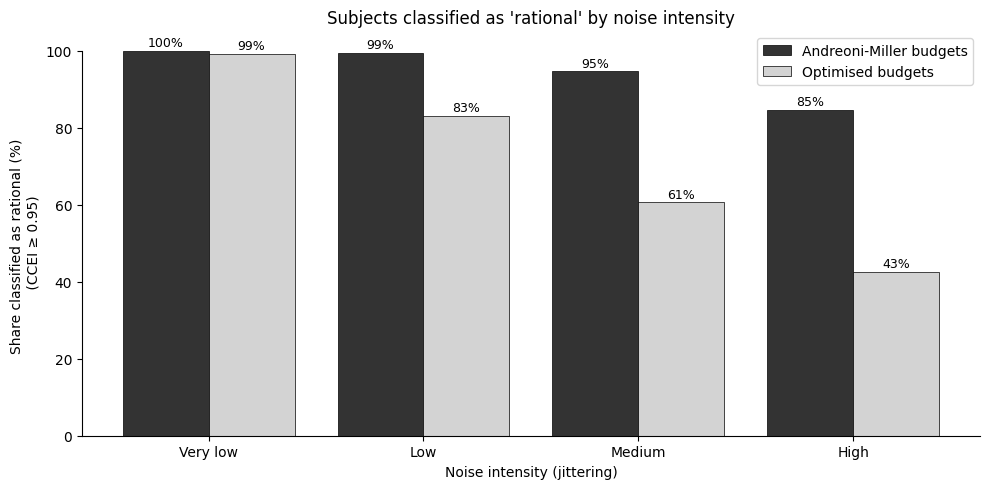

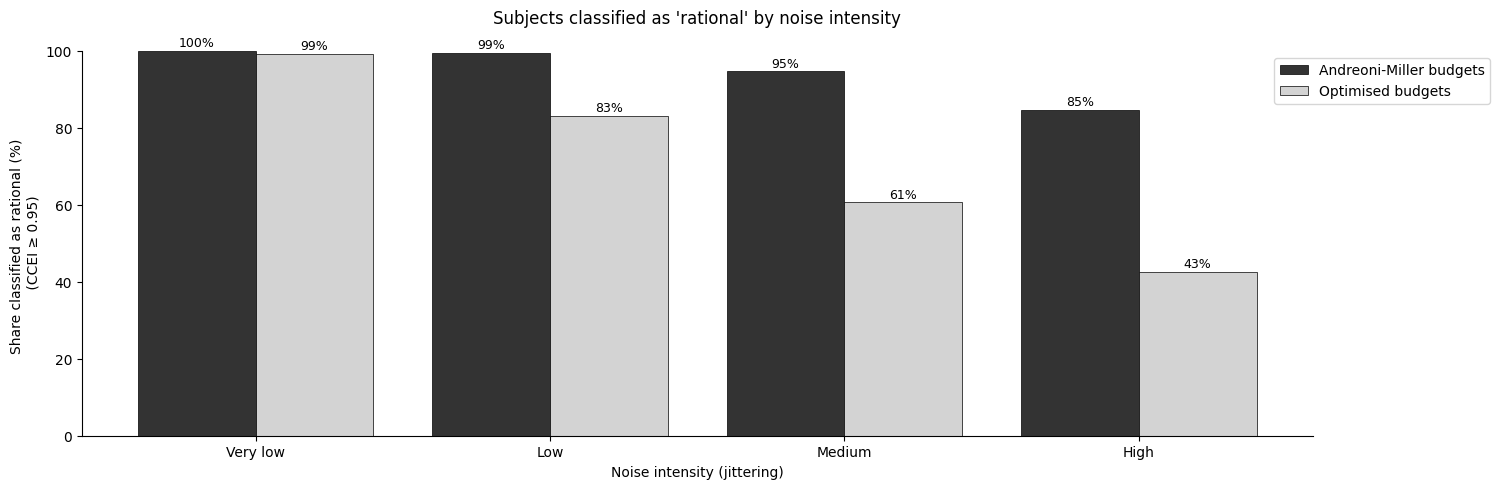

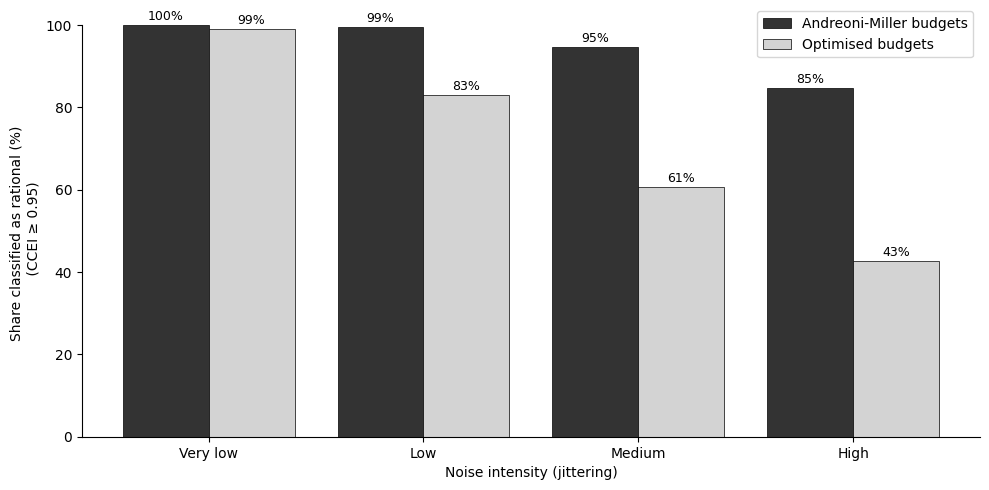

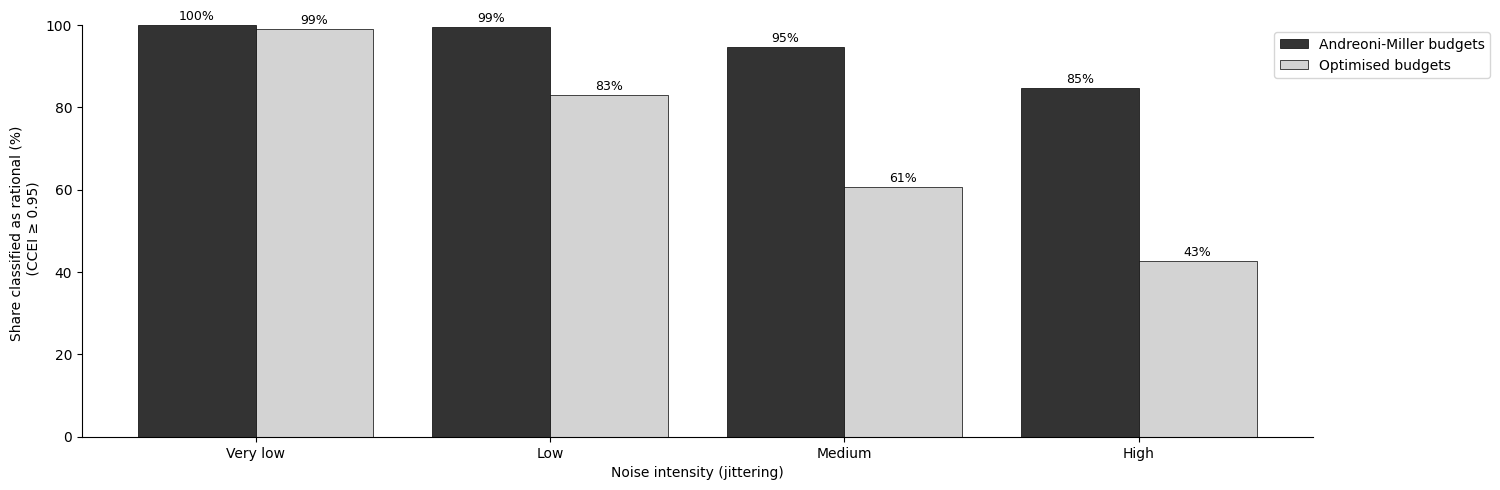

In [10]:
plot_classification_irrational(df_andreoni_miller, 
                               df_optimized, 
                               title = "Subjects classified as 'rational' by noise intensity",
                               palette = ["#333333", "#d3d3d3"],
                               legend_anchor=(1,1.05),
                               figsize=(10,5),
                               save=True,
                               savepath=figures+"title_v1.png")

plot_classification_irrational(df_andreoni_miller, 
                               df_optimized, 
                               title = "Subjects classified as 'rational' by noise intensity",
                               palette = ["#333333", "#d3d3d3"],
                               legend_anchor=(1.15,1),
                               figsize=(15,5),
                               save=True,
                               savepath=figures+"title_v2.png")

plot_classification_irrational(df_andreoni_miller, 
                               df_optimized, 
                               #title = "Subjects classified as 'rational' by noise intensity",
                               palette = ["#333333", "#d3d3d3"],
                               legend_anchor=(1,1.05),
                               figsize=(10,5),
                               save=True,
                               savepath=figures+"no_title_v1.png")

plot_classification_irrational(df_andreoni_miller, 
                               df_optimized, 
                               #title = "Subjects classified as 'rational' by noise intensity",
                               palette = ["#333333", "#d3d3d3"],
                               legend_anchor=(1.15,1),
                               figsize=(15,5),
                               save=True,
                               savepath=figures+"no_title_v2.png")